In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Original line parameters
m = 5
b = 2

# Create X values
x0 = np.arange(0,1.01,0.01)

# Sort X (required by assignment)
x0 = np.sort(x0)

# Random error between -1 and 1
error = np.random.uniform(-1,1,len(x0))

# Generate Y data
y0 = m*x0 + b + error

# Design matrix
A0 = np.vstack([x0, np.ones(len(x0))]).T

print("X:", x0)
print("A:", A0)

# Numpy LSQ


m_np, b_np = np.linalg.lstsq(A0, y0, rcond=None)[0]

print("\nNumPy Solution")
print("Slope:", m_np)
print("Intercept:", b_np)

# -----------------------------
# MANUAL LEAST SQUARES METHOD
# -----------------------------

n = len(x0)

sum_x = np.sum(x0)
sum_y = np.sum(y0)
sum_xy = np.sum(x0*y0)
sum_x2 = np.sum(x0**2)

m_manual = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
b_manual = (sum_y - m_manual*sum_x)/n

print("\nManual Least Squares Solution")
print("Slope:", m_manual)
print("Intercept:", b_manual)

X: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]
A: [[0.   1.  ]
 [0.01 1.  ]
 [0.02 1.  ]
 [0.03 1.  ]
 [0.04 1.  ]
 [0.05 1.  ]
 [0.06 1.  ]
 [0.07 1.  ]
 [0.08 1.  ]
 [0.09 1.  ]
 [0.1  1.  ]
 [0.11 1.  ]
 [0.12 1.  ]
 [0.13 1.  ]
 [0.14 1.  ]
 [0.15 1.  ]
 [0.16 1.  ]
 [0.17 1.  ]
 [0.18 1.  ]
 [0.19 1.  ]
 [0.2  1.  ]
 [0.21 1.  ]
 [0.22 1.  ]
 [0.23 1.  ]
 [0.24 1.  ]
 [0.25 1.  ]
 [0.26 1.  ]
 [0.27 1.  ]
 [0.28 1.  ]
 [0.29 1.  ]
 [0.3  1.  ]
 [0.31 1.  ]
 [0.32 1.  ]
 [0.33 1.  ]
 [0.34 1.  ]
 [0.35 1.  ]
 [0.36 1.  ]

In [3]:
# Residuals

y_pred = m_np*x0 + b_np
residuals = y0 - y_pred

print("\nResiduals:")
print(residuals)

# Largest and smallest residual
largest_index = np.argmax(np.abs(residuals))
smallest_index = np.argmin(np.abs(residuals))

print("\nLargest Residual:")
print("Index:", largest_index)
print("X:", x0[largest_index])
print("Residual:", residuals[largest_index])

print("\nSmallest Residual:")
print("Index:", smallest_index)
print("X:", x0[smallest_index])
print("Residual:", residuals[smallest_index])


Residuals:
[-0.24199238 -0.08977776  0.89468116 -0.73687319  0.15938747  0.14456854
  0.1453005   0.98259498 -0.97736253 -0.79862116 -0.08027412 -0.51130847
 -0.16812847  0.02743063 -0.29288853  0.94282327  0.40880204 -0.62537278
  0.78216561  0.17752034 -0.50001449  0.01724597 -0.07980009  0.8265577
 -0.64096559 -0.83747596 -0.40918337  0.7636777  -0.39886196  0.26984135
 -0.19259205  0.59376197 -0.61498608 -0.94347749  0.34341925 -0.51228515
  0.55144669  0.27459033  0.16639305  0.66938231  0.24859607  0.06292326
  0.8325446  -0.46781745 -0.53053406 -0.07961792  0.23536525  0.08087767
  0.46629709 -0.97881551  0.8017132   0.11318122 -0.48048941  0.1487862
  0.09168815 -0.16332624 -0.60359164  0.33806325 -0.6728234   0.13526085
 -0.50676016 -0.55254705  0.70815282 -0.71490363  0.89891387  0.81206503
  0.91233441  0.3998799   0.38385216  0.37718564 -0.03658588 -0.07872565
 -0.78740452 -0.79024025  0.91145625  0.15187161  0.24118866 -1.01143342
  0.78322129  0.33747209  0.14510511 -0.3

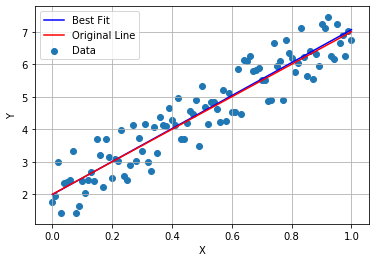

In [4]:
# Plotting it

plt.figure()
plt.grid(True)

plt.xlabel("X")
plt.ylabel("Y")

# Scatter points
plt.scatter(x0,y0,label="Data")

# Best fit line
yline = m_np*x0 + b_np

# Original line
yline2 = m*x0 + b

plt.plot(x0,yline,'blue',label="Best Fit")
plt.plot(x0,yline2,'red',label="Original Line")

plt.legend()

plt.show()

In [5]:
print("\nOriginal equation: y =",m,"x +",b)
print("Estimated equation: y =",m_np,"x +",b_np)


Original equation: y = 5 x + 2
Estimated equation: y = 5.071146286285175 x + 1.9927303300584687
